# Definición de variable objetivo

In [67]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibilidad
RANDOM_STATE = 42

# Función de conexión
def cargar_datos_sqlite(db_path):
    """
    Establece conexión con SQLite y carga las tablas
    """
    try:
        con = sqlite3.connect(db_path)
        # Carga directa mediante SQL
        df_accidentes = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
        df_clima = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
        df_raw = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])
        con.close()
        print("Conexión exitosa, tablas cargadas.")
        return df_accidentes, df_clima, df_raw
    except Exception as e:
        print(f"Error al conectar: {e}")
        return None, None, None

# Ejecución de la carga
accidentes, clima, raw = cargar_datos_sqlite('data_accidentes.sqlite3')

Conexión exitosa, tablas cargadas.


In [68]:
def crear_dataset_objetivo(df_clima, df_accidentes):
    # Asegurarnos de que no existan duplicados en las llaves antes del join
    clima_clean = df_clima.drop_duplicates(subset=['TW', 'BARRIO'])
    acc_clean = df_accidentes.drop_duplicates(subset=['TW', 'BARRIO'])

    # Realizar el Left Join usando indicator=True
    # Esto creará una columna especial llamada '_merge'
    df_merged = pd.merge(
        clima_clean,
        acc_clean[['TW', 'BARRIO']], # Solo necesitamos las llaves para marcar presencia
        on=['TW', 'BARRIO'],
        how='left',
        indicator=True
    )

    # El target será 1 si la fila está en 'both' (ambas tablas)
    # y 0 si solo está en 'left_only' (solo en clima)
    df_merged['target'] = (df_merged['_merge'] == 'both').astype(int)

    # Eliminamos la columna indicadora para limpiar el dataset
    df_merged = df_merged.drop(columns=['_merge'])

    return df_merged

# Ejecución
df_final = crear_dataset_objetivo(clima, accidentes)
print(f"Distribución del target:\n{df_final['target'].value_counts(normalize=True)}")

Distribución del target:
target
0    0.984925
1    0.015075
Name: proportion, dtype: float64


## ¿Cómo se definió la unidad de análisis?

La unidad de análisis es la combinación Barrio-Hora, es decir, cada fila representa un bloque de 60 minutos en una localización específica. Es una granularidad adecuada para el problema

## ¿Cómo se construyeron los casos negativos?

Se asume que si en la tabla clima existe un registro para el Barrio $B$ en la Hora $H$, pero ese registro no existe en la tabla accidentes, es porque en ese lapso no ocurrió ningún evento reportado. Se hace un Join y en consecuencia, si hay registro de hora en ambas tablas, se marca como 1 la columna target, si solo está en clima, se marca como 0

## ¿Qué proporción quedó de la clase positiva?

La Distribución del target fue de la siguiente manera:

0  -  0.984925 (98.5%)

1  -  0.015075 (1.5%)

La clase positiva representa la minoría, siendo solo el 1.5% de los datos, evidenciando entonces un claro caso de desbalanceo de clases.

# EDA

In [69]:
def extraer_componentes_temporales(df):
    """Extrae características de tiempo del objeto Timestamp."""
    df = df.copy()
    df['hora'] = df['TW'].dt.hour
    df['dia_semana'] = df['TW'].dt.dayofweek # 0=Lunes, 6=Domingo
    df['mes'] = df['TW'].dt.month
    return df

df_final = extraer_componentes_temporales(df_final)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7180\4093736502.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hora', data=df_acc, ax=axes[0], palette='viridis')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7180\4093736502.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='dia_semana', data=df_acc, ax=axes[1], palette='magma')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7180\4093736502.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='mes', data=df_acc, ax=axes[2], palette='rocket')


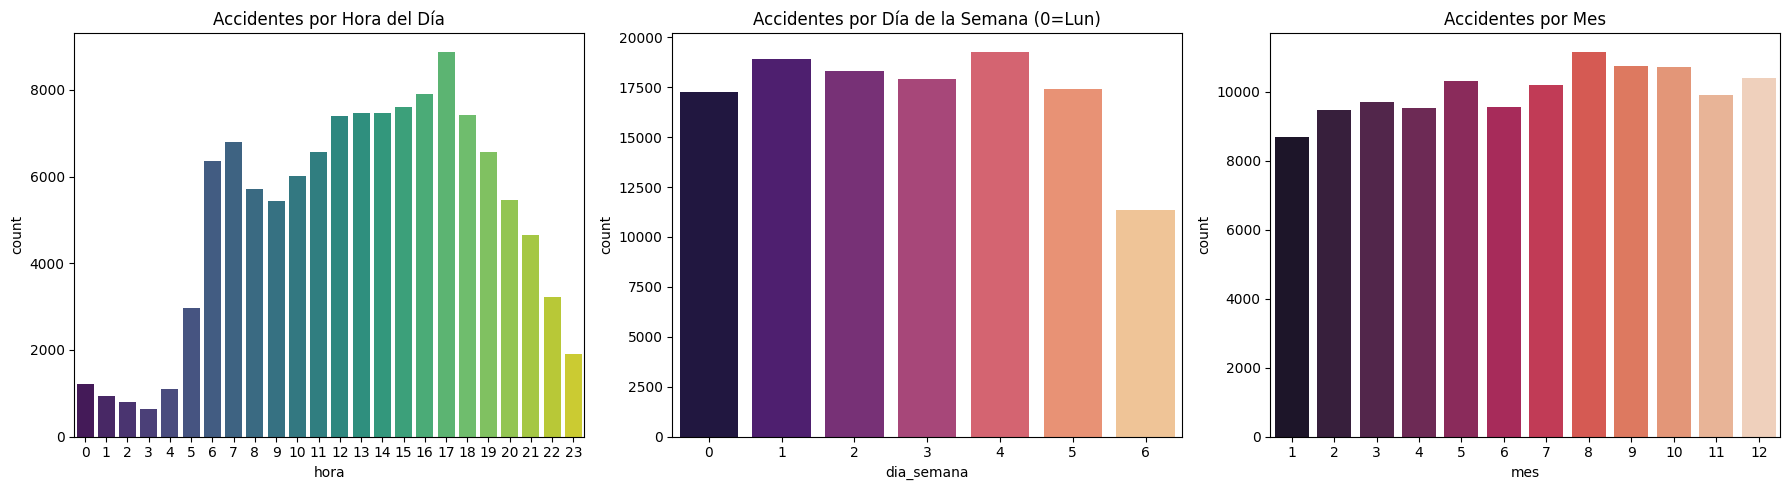

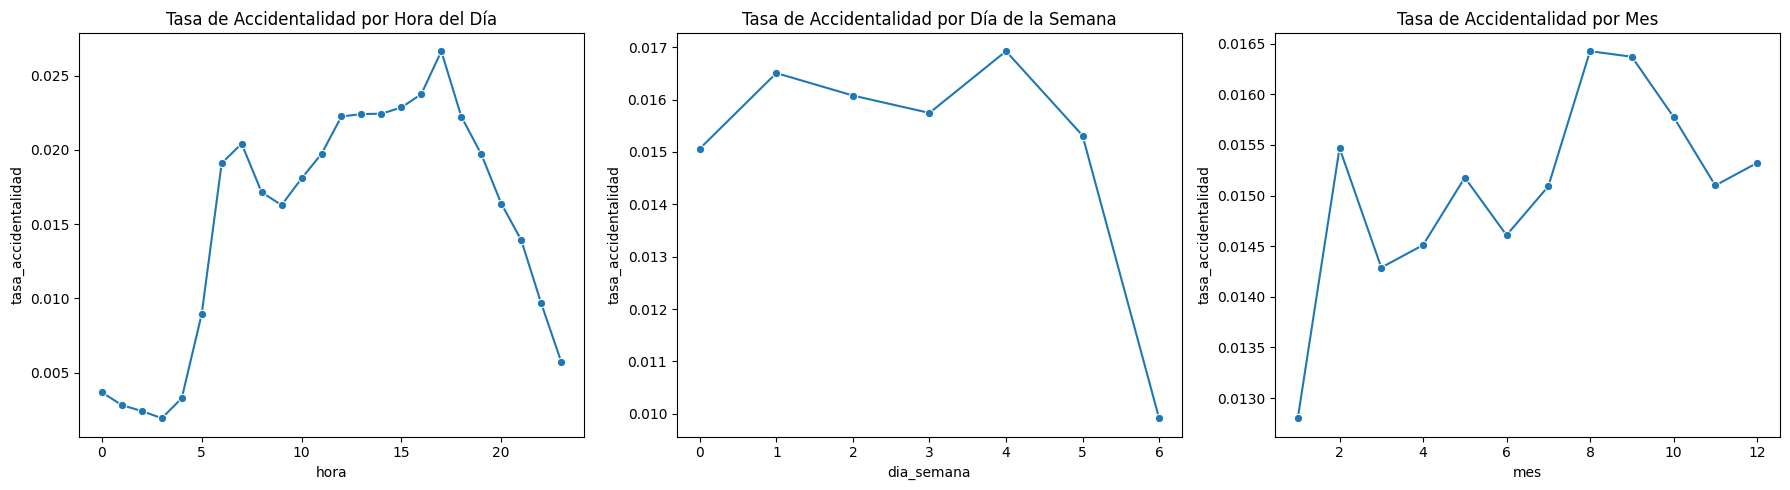

In [70]:
# Distribución temporal de los accidentes, por hora, día y mes

def plot_distribucion_temporal(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Solo nos interesan los registros donde hubo accidente para este análisis descriptivo
    df_acc = df[df['target'] == 1]

    sns.countplot(x='hora', data=df_acc, ax=axes[0], palette='viridis')
    axes[0].set_title('Accidentes por Hora del Día')

    sns.countplot(x='dia_semana', data=df_acc, ax=axes[1], palette='magma')
    axes[1].set_title('Accidentes por Día de la Semana (0=Lun)')

    sns.countplot(x='mes', data=df_acc, ax=axes[2], palette='rocket')
    axes[2].set_title('Accidentes por Mes')

    plt.tight_layout()
    plt.show()

def plot_tasa_temporal(df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    tasa_hora = (
        df.groupby('hora')
        .agg(total_observaciones=('target', 'count'), accidentes=('target', 'sum'), tasa_accidentalidad=('target', 'mean'))
        .reset_index()
    )

    tasa_dia = (
        df.groupby('dia_semana')
        .agg(total_observaciones=('target', 'count'), accidentes=('target', 'sum'), tasa_accidentalidad=('target', 'mean'))
        .reset_index()
    )

    tasa_mes = (
        df.groupby('mes')
        .agg(total_observaciones=('target', 'count'), accidentes=('target', 'sum'), tasa_accidentalidad=('target', 'mean'))
        .reset_index()
    )

    sns.lineplot(data=tasa_hora, x='hora', y='tasa_accidentalidad', marker='o', ax=axes[0])
    axes[0].set_title('Tasa de Accidentalidad por Hora del Día')

    sns.lineplot(data=tasa_dia, x='dia_semana', y='tasa_accidentalidad', marker='o', ax=axes[1])
    axes[1].set_title('Tasa de Accidentalidad por Día de la Semana')

    sns.lineplot(data=tasa_mes, x='mes', y='tasa_accidentalidad', marker='o', ax=axes[2])
    axes[2].set_title('Tasa de Accidentalidad por Mes')

    plt.tight_layout()
    plt.show()


plot_distribucion_temporal(df_final)
plot_tasa_temporal(df_final)

Se evidencia un comportamiento interesante en la accidentalidad por hora del día, siendo baja en horas de la madrugada, teniendo su máximo a las 17:00 y bajando a partir de ahí

Podemos ver cómo la accidentalidad es considerablemente menor el domingo comparada con los demás días de la semana

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7180\2672397988.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='Blues_r')


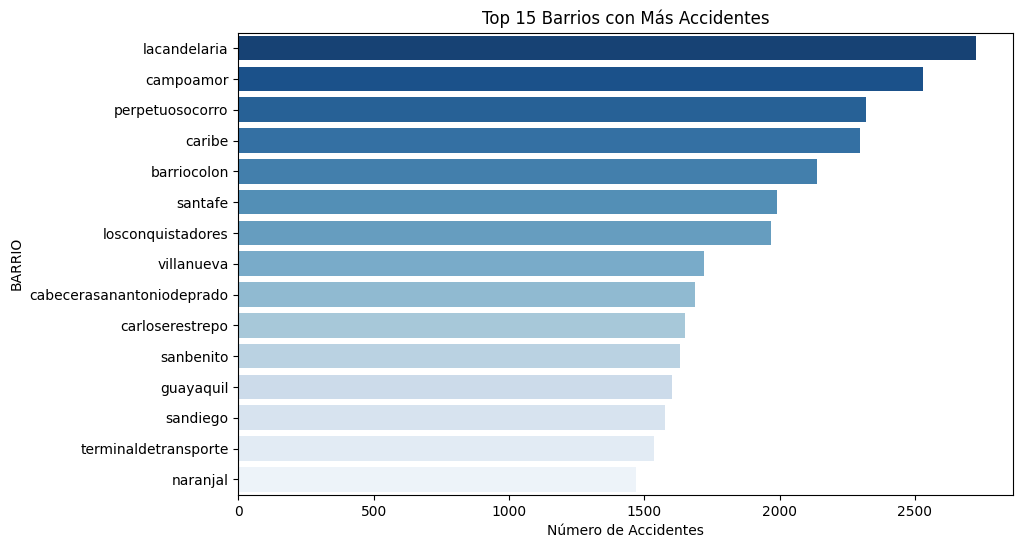

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7180\2672397988.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_comunas.values, y=top_comunas.index, palette='Blues_r')


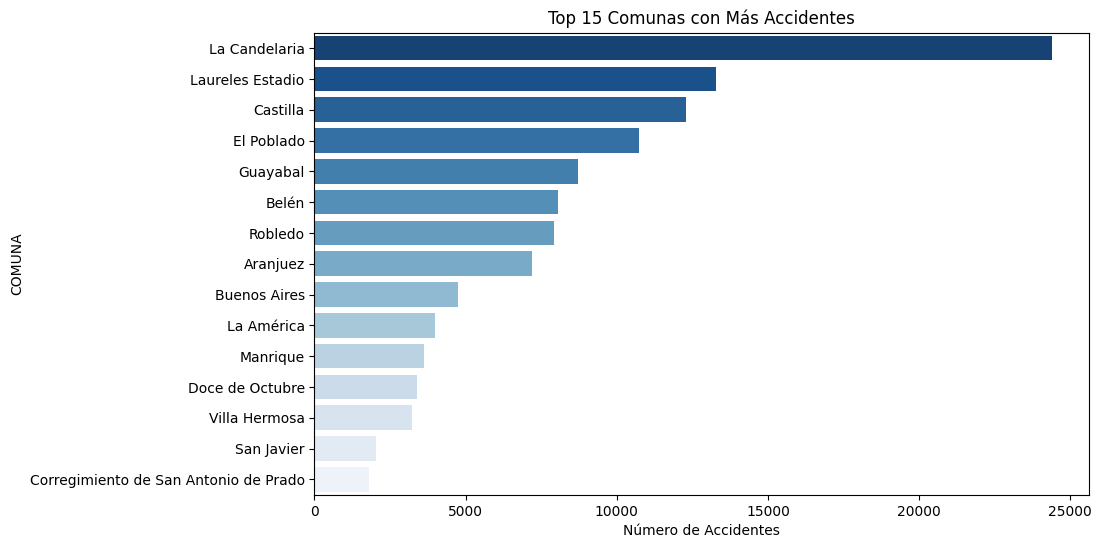

In [71]:
# Distribución espacial de los accidentes

# Usamos la tabla raw_accidentes para determinar la comuna donde ocurrió el accidente
df_barrio_comuna = (
    raw[['BARRIO', 'COMUNA']]
    .dropna()
    .groupby('BARRIO')['COMUNA']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .reset_index()
)

df_final = df_final.merge(df_barrio_comuna, on='BARRIO', how='left')


def plot_top_barrios(df, n=15):
    plt.figure(figsize=(10, 6))
    top_barrios = df[df['target'] == 1]['BARRIO'].value_counts().head(n)
    sns.barplot(x=top_barrios.values, y=top_barrios.index, palette='Blues_r')
    plt.title(f'Top {n} Barrios con Más Accidentes')
    plt.xlabel('Número de Accidentes')
    plt.show()

def plot_top_comunas(df, n=15):
    plt.figure(figsize=(10, 6))
    top_comunas = df[df['target'] == 1]['COMUNA'].value_counts().head(n)
    sns.barplot(x=top_comunas.values, y=top_comunas.index, palette='Blues_r')
    plt.title(f'Top {n} Comunas con Más Accidentes')
    plt.xlabel('Número de Accidentes')
    plt.show()


plot_top_barrios(df_final)
plot_top_comunas(df_final)

Se observa cómo el barrio y la comuna de mayor accidentalidad reportada es La Candelaria

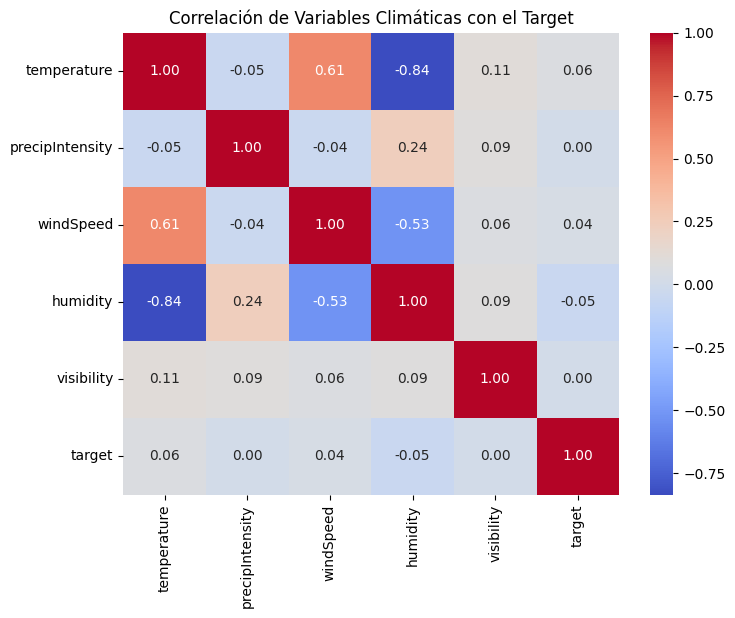

In [72]:
# Caracterización del clima

def analizar_clima_target(df):
    # Seleccionar variables climáticas relevantes
    cols_clima = ['temperature', 'precipIntensity', 'windSpeed', 'humidity', 'visibility', 'target']

    # Matriz de Correlación
    plt.figure(figsize=(8, 6))
    sns.heatmap(df[cols_clima].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlación de Variables Climáticas con el Target')
    plt.show()

analizar_clima_target(df_final)

En la matriz de correlación no se evidencia ninguna correlación fuerte, ya sea positiva o negativa entre alguna variable climática y el target, esto no significa que las variables climáticas no influyan en la accidentalidad, sino que el análisis en la matriz de correlación no es lo suficientemente revelador por varios factores, como que el target es una variable binaria, por lo que es necesario usar otros métodos para capturar la relación

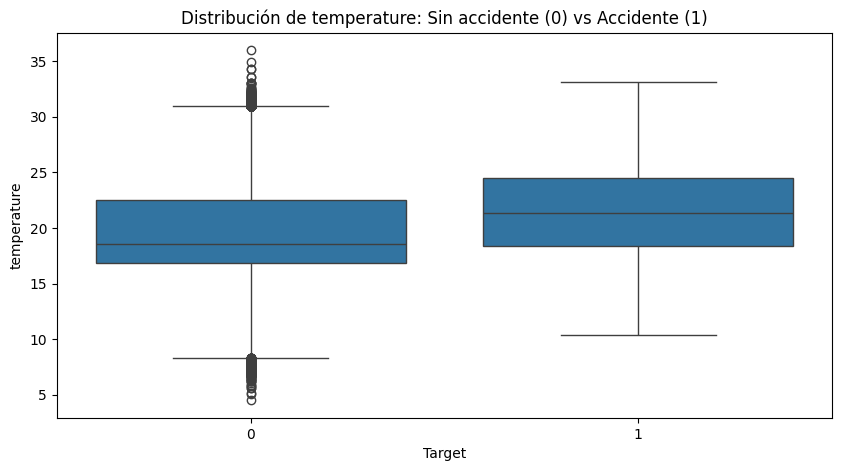

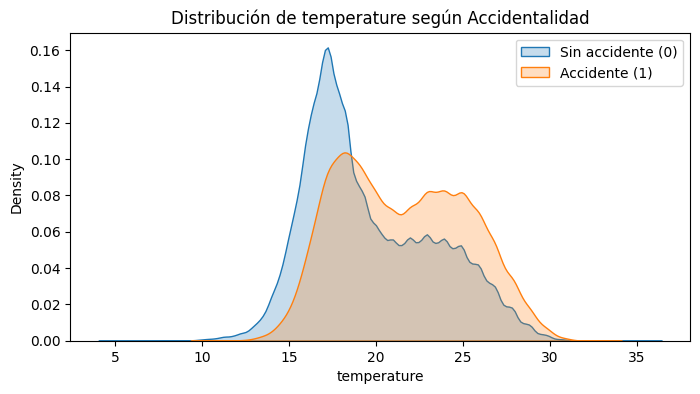

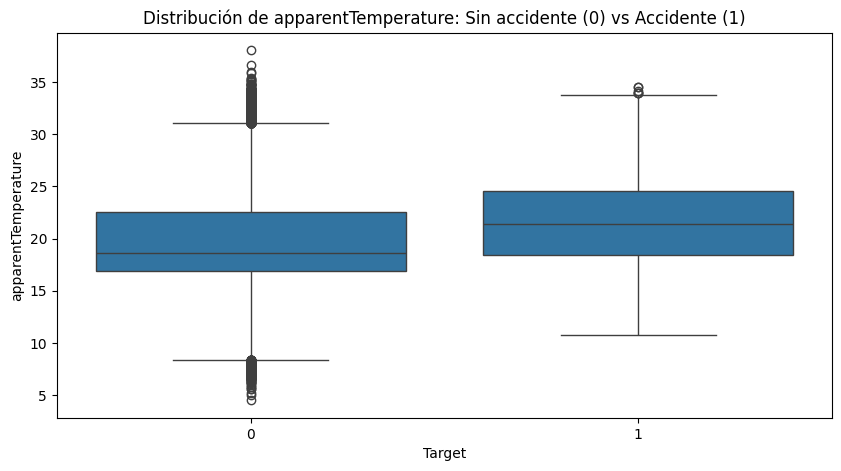

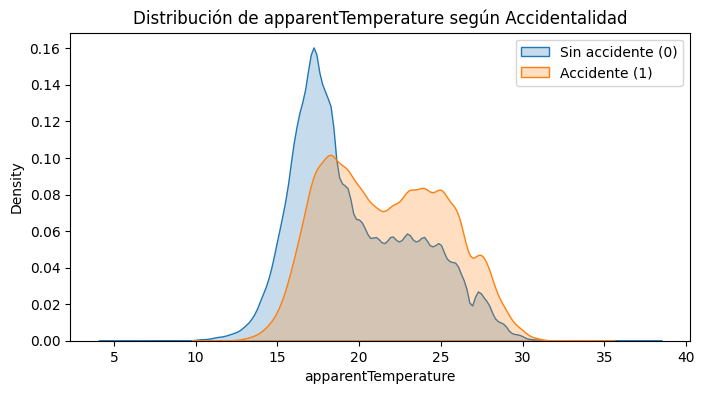

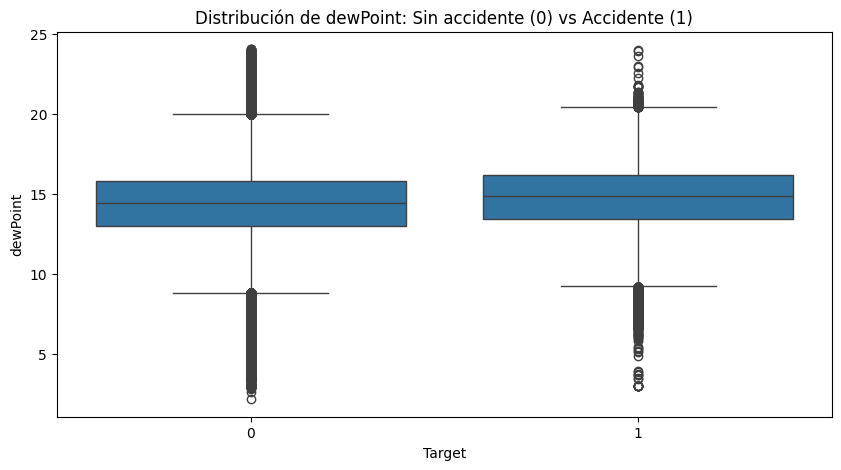

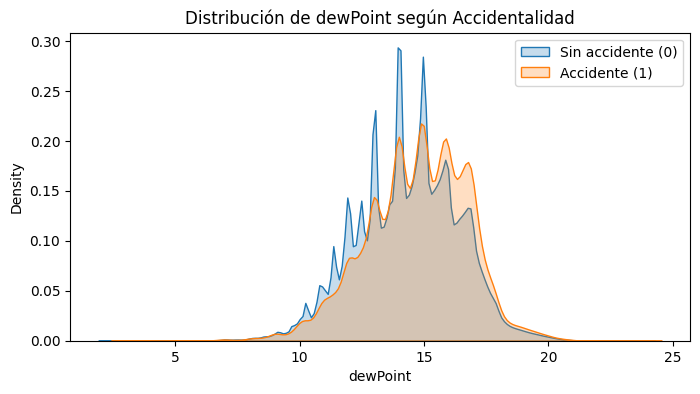

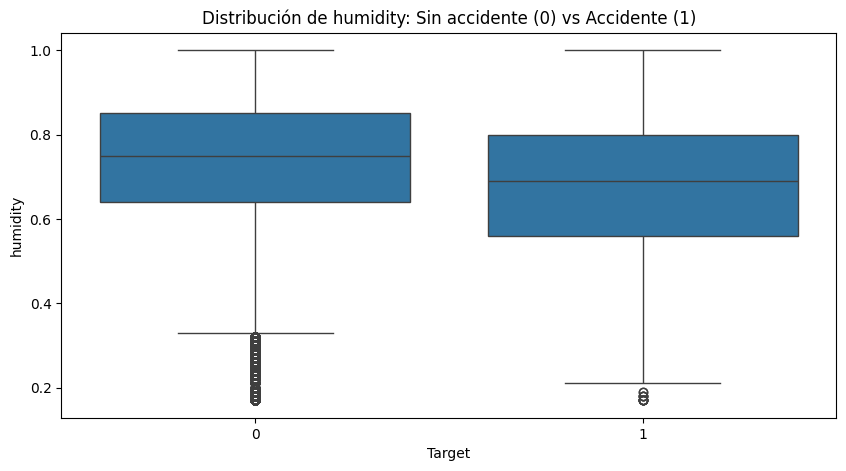

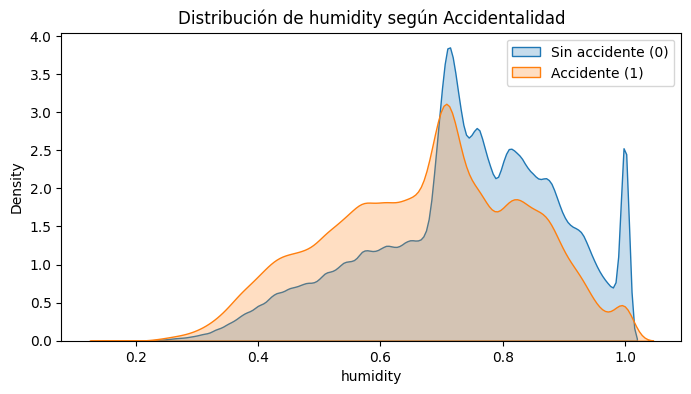

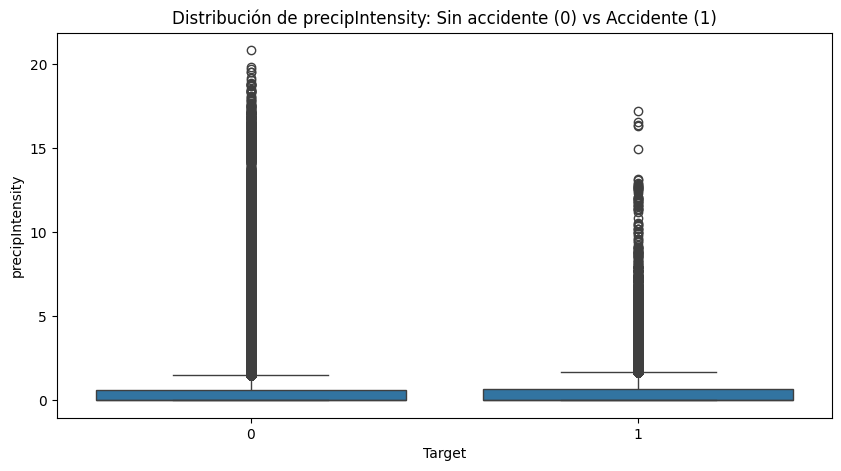

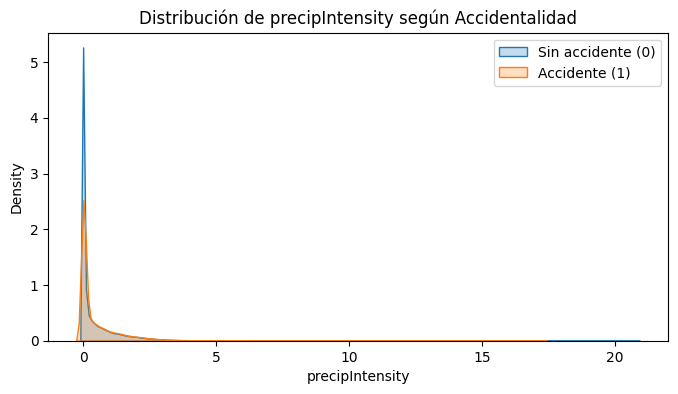

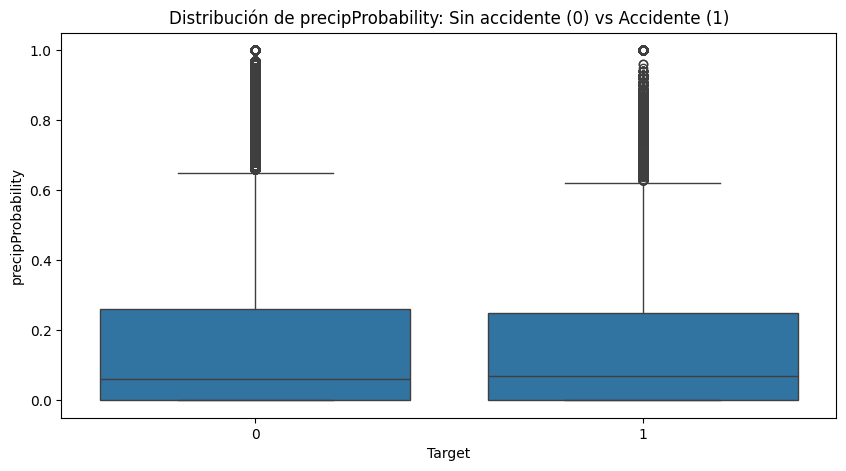

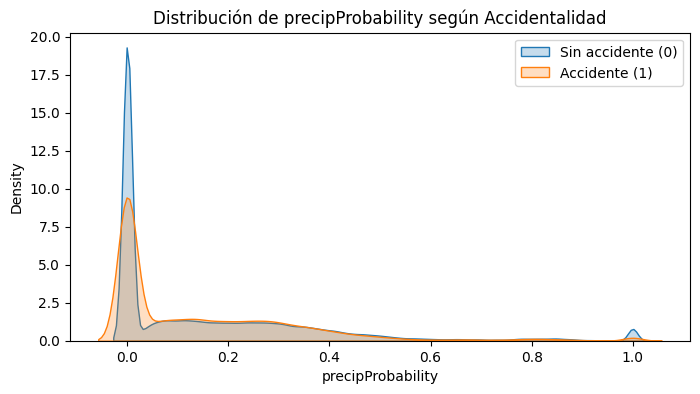

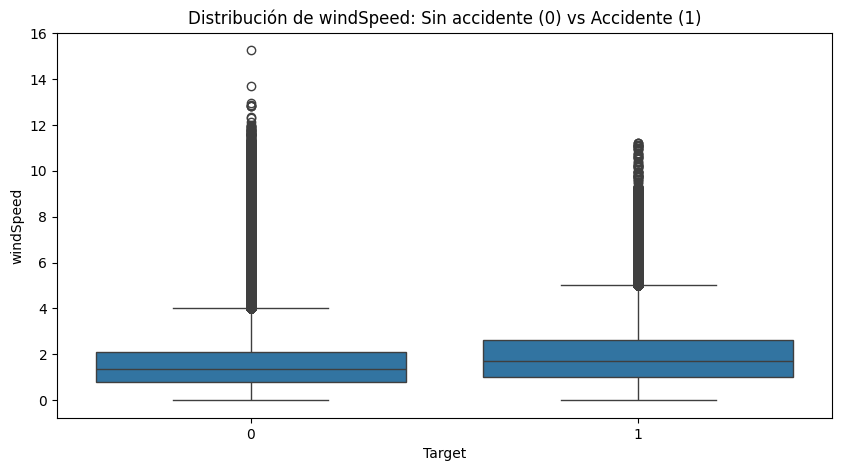

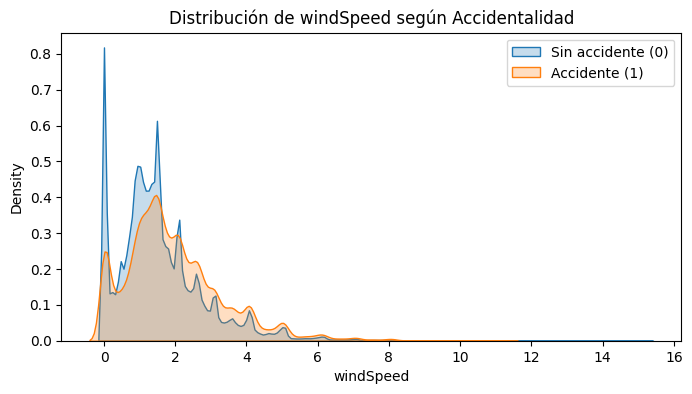

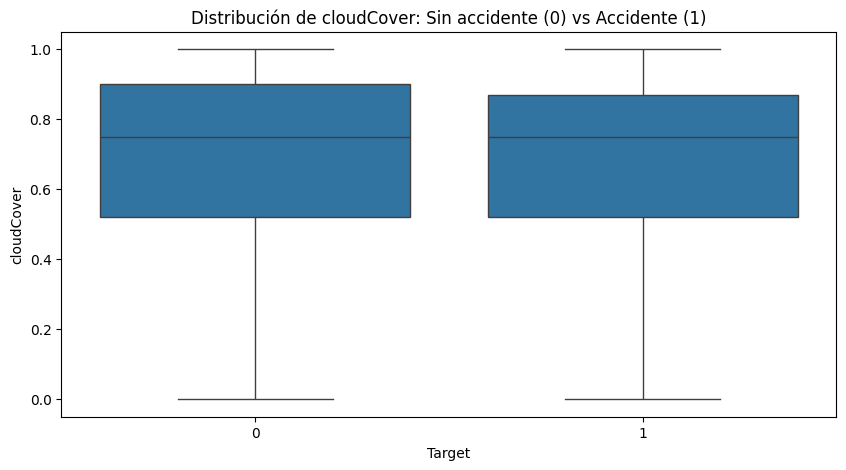

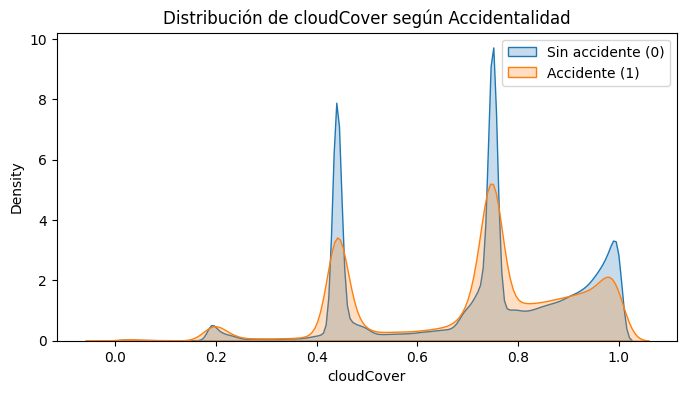

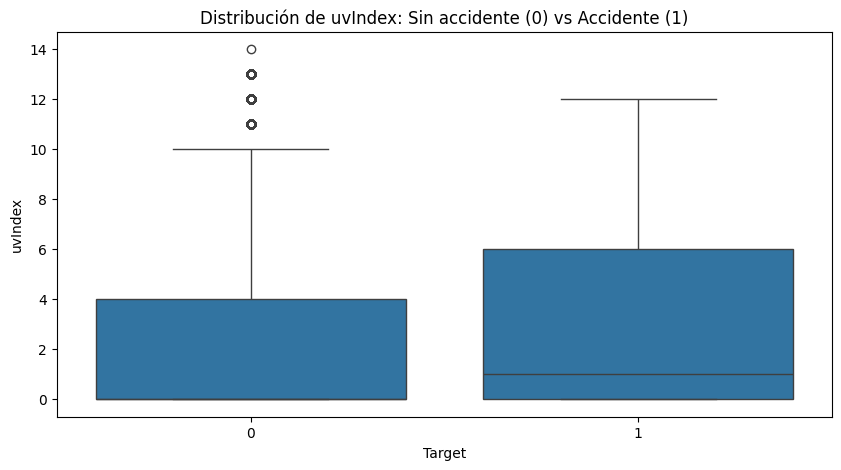

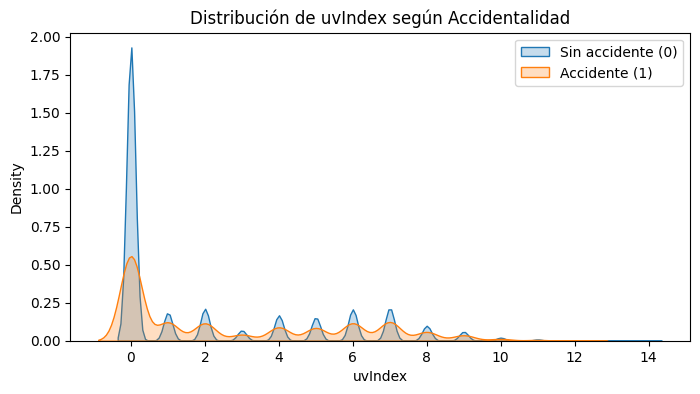

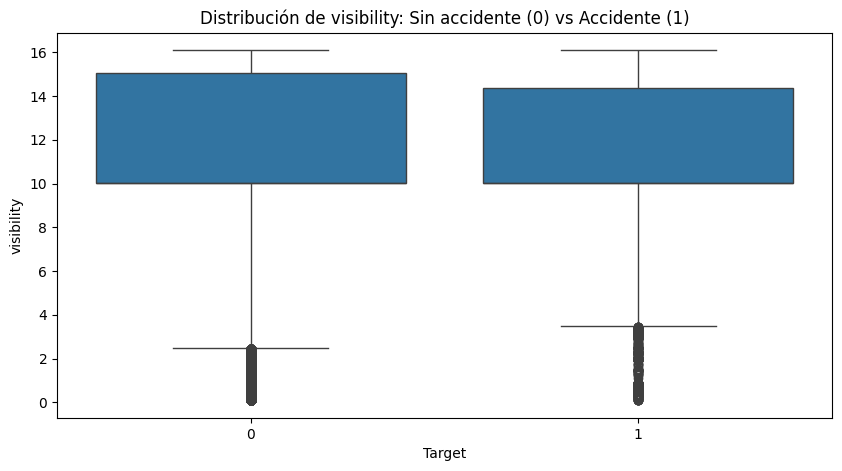

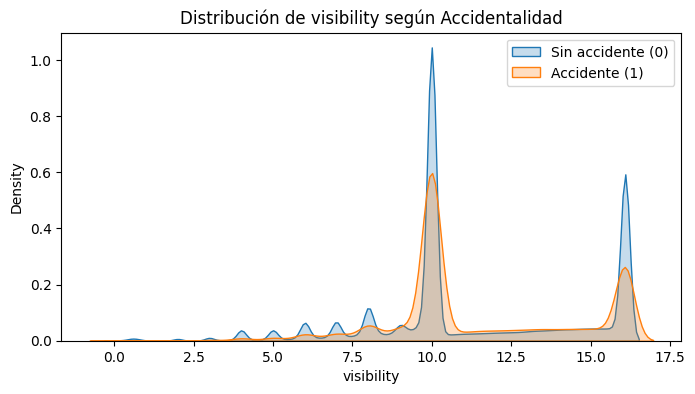

In [73]:
# Observamos las distribuciones de las variables tanto para accidentes como para sin ellos
def plot_boxplot_variable(df, variable):
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='target', y=variable, data=df)
    plt.title(f'Distribución de {variable}: Sin accidente (0) vs Accidente (1)')
    plt.xlabel('Target')
    plt.ylabel(variable)
    plt.show()

def plot_comparacion_distribuciones(df, variable):
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df[df['target']==0], x=variable, label='Sin accidente (0)', fill=True)
    sns.kdeplot(data=df[df['target']==1], x=variable, label='Accidente (1)', fill=True)
    plt.title(f'Distribución de {variable} según Accidentalidad')
    plt.legend()
    plt.show()

variables_clima = [
    'temperature', 'apparentTemperature', 'dewPoint',
    'humidity', 'precipIntensity', 'precipProbability',
    'windSpeed', 'cloudCover', 'uvIndex', 'visibility'
]
for variable in variables_clima:
    plot_boxplot_variable(df_final, variable)
    plot_comparacion_distribuciones(df_final, variable)


In [74]:
resumen_clima_target = (
    df_final
    .groupby('target')[variables_clima]
    .agg(['mean', 'median', 'std'])
)

resumen_clima_target

temperature                  apparentTemperature                   \
              mean median       std                mean median       std   
target                                                                     
0        19.624997  18.57  3.746981           19.698304  18.67  3.751562   
1        21.535629  21.34  3.684016           21.615155  21.43  3.685750   

         dewPoint                   humidity  ... windSpeed cloudCover         \
             mean median       std      mean  ...       std       mean median   
target                                        ...                               
0       14.332735  14.41  2.032198  0.735288  ...  1.254486   0.722608   0.75   
1       14.722896  14.89  2.018665  0.673776  ...  1.412568   0.711025   0.75   

                   uvIndex                  visibility                    
             std      mean median       std       mean  median       std  
target                                                                    
0       0.207940  1.992976    0.0  2.865402  11.316265  10.003  3.402731  
1       0.207232  2.781610    1.0  3.064163  11.417221  10.003  3.037097  

[2 rows x 30 columns]

In [75]:
medianas_clima = df_final.groupby('target')[variables_clima].median().T

medianas_clima.columns = ['sin_accidente_0', 'accidente_1']

medianas_clima['diferencia_mediana'] = (
    medianas_clima['accidente_1'] - medianas_clima['sin_accidente_0']
)

medianas_clima = medianas_clima.sort_values(
    'diferencia_mediana',
    ascending=False
)

medianas_clima

,sin_accidente_0,accidente_1,diferencia_mediana
temperature,18.5700,21.3400,2.770
apparentTemperature,18.6700,21.4300,2.760
uvIndex,0.0000,1.0000,1.000
dewPoint,14.4100,14.8900,0.480
windSpeed,1.3600,1.6900,0.330
precipProbability,0.0600,0.0700,0.010
precipIntensity,0.0301,0.0361,0.006
cloudCover,0.7500,0.7500,0.000
visibility,10.0030,10.0030,0.000
humidity,0.7500,0.6900,-0.060


Al comparar las variables climáticas entre registros sin accidente y con accidente, se observa que no existe una separación perfecta entre ambas clases. Las distribuciones presentan un alto grado de solapamiento, lo cual indica que el clima por sí solo no explica completamente la ocurrencia de accidentes.

Sin embargo, algunas variables muestran diferencias sistemáticas. Las variables temperature y apparentTemperature presentan las mayores diferencias de mediana, con valores aproximadamente 2.7 unidades superiores en los registros con accidente. Esto sugiere que las condiciones más cálidas podrían estar asociadas con una mayor accidentalidad observada.

También se identifican diferencias moderadas en uvIndex, dewPoint y windSpeed. En particular, windSpeed presenta una mediana mayor en los registros con accidente, lo que indica una posible señal débil relacionada con el viento. Por otro lado, humidity muestra una mediana menor en los casos con accidente.

Las variables de precipitación, precipIntensity y precipProbability, presentan diferencias pequeñas entre clases y una alta concentración de valores cercanos a cero. Por esta razón, para la fase de ingeniería de características crearemos variables derivadas como llueve y alta_prob_lluvia, que pueden capturar mejor la presencia o ausencia de lluvia.

En conclusión, las variables climáticas no parecen tener una capacidad discriminante fuerte de manera individual, pero sí aportan señales útiles que pueden complementar las variables temporales, espaciales e históricas dentro del modelo predictivo.

# Calidad de Datos

In [76]:
for nombre, df in {
    'accidentes': accidentes,
    'clima': clima,
    'raw': raw
}.items():
    print(f'\n--- {nombre} ---')
    print(df.shape)
    print(df.dtypes)
    print('TW mínimo:', df['TW'].min())
    print('TW máximo:', df['TW'].max())
    print('Nulos en TW:', df['TW'].isna().sum())


--- accidentes ---
(120587, 8)
TW         datetime64[us]
BARRIO                str
Lat               float64
Lon               float64
Dia_sem               str
Mes                 int64
Dia                 int64
Hora                int64
dtype: object
TW mínimo: 2017-01-01 00:00:00
TW máximo: 2019-12-31 23:00:00
Nulos en TW: 0

--- clima ---
(7991780, 15)
TW                     datetime64[us]
BARRIO                            str
summary                           str
icon                              str
precipIntensity               float64
precipProbability             float64
temperature                   float64
apparentTemperature           float64
dewPoint                      float64
humidity                      float64
windSpeed                     float64
windBearing                   float64
cloudCover                    float64
uvIndex                       float64
visibility                    float64
dtype: object
TW mínimo: 2017-01-01 00:00:00
TW máximo: 2019-12-31 23:

In [77]:
for nombre, df in {'accidentes': accidentes, 'clima': clima, 'raw': raw}.items():
    minutos_no_cero = (df['TW'].dt.minute != 0).sum()
    segundos_no_cero = (df['TW'].dt.second != 0).sum()
    print(nombre, minutos_no_cero, segundos_no_cero)

accidentes 0 0
clima 0 0
raw 0 0


Se verificó la estructura general de las tres tablas disponibles. Las tablas accidentes, clima y raw_accidentes cubren el mismo período temporal, desde el 1 de enero de 2017 hasta el 31 de diciembre de 2019. Además, en las tres tablas la columna TW fue cargada correctamente como tipo datetime64, no presenta valores nulos y se encuentra truncada a la hora, ya que no se identificaron registros con minutos o segundos diferentes de cero.

Esto confirma que TW puede utilizarse como llave temporal confiable para unir las tablas a nivel horario. La consistencia del rango temporal entre las tres fuentes también indica que no hay desfases evidentes de cobertura temporal entre accidentes, clima y registros crudos.

In [78]:
def revisar_duplicados_llave(df, nombre):
    duplicados = df.duplicated(subset=['TW', 'BARRIO']).sum()
    print(f'{nombre}: {duplicados} duplicados en la llave TW-BARRIO')

    if duplicados > 0:
        display(
            df[df.duplicated(subset=['TW', 'BARRIO'], keep=False)]
            .sort_values(['BARRIO', 'TW'])
            .head(20)
        )

revisar_duplicados_llave(clima, 'clima')
revisar_duplicados_llave(accidentes, 'accidentes')

clima: 0 duplicados en la llave TW-BARRIO
accidentes: 0 duplicados en la llave TW-BARRIO


La llave compuesta TW-BARRIO es consistente en las dos tablas principales que se van a unir. En clima, cada fila representa una única medición climática para un barrio y una hora. En accidentes, cada fila representa una combinación barrio-hora donde ocurrió al menos un accidente.

Esto es positivo porque permite hacer el merge sin riesgo de duplicar filas artificialmente.

In [79]:
barrios_clima = set(clima['BARRIO'].dropna().unique())
barrios_acc = set(accidentes['BARRIO'].dropna().unique())
barrios_raw = set(raw['BARRIO'].dropna().unique())

print('Barrios en clima:', len(barrios_clima))
print('Barrios en accidentes:', len(barrios_acc))
print('Barrios en raw:', len(barrios_raw))

print('Barrios en accidentes que no están en clima:', len(barrios_acc - barrios_clima), barrios_acc - barrios_clima)
print('Barrios en raw que no están en clima:', len(barrios_raw - barrios_clima), barrios_raw - barrios_clima)

sorted([b for b in clima['BARRIO'].unique() if 'aguas' in b])
sorted([b for b in clima['BARRIO'].unique() if 'astill' in b])
sorted([b for b in clima['BARRIO'].unique() if 'yarum' in b])

Barrios en clima: 319
Barrios en accidentes: 322
Barrios en raw: 322
Barrios en accidentes que no están en clima: 3 {'yarumalito', 'suburbanoaguasfrias', 'elastillero'}
Barrios en raw que no están en clima: 3 {'yarumalito', 'suburbanoaguasfrias', 'elastillero'}


[]

Se identificaron 3 barrios presentes en accidentes y raw_accidentes que no aparecen en clima: yarumalito, suburbanoaguasfrias y elastillero. Dado que la tabla clima define el universo de combinaciones barrio-hora con variables predictoras, estos barrios no pueden incorporarse directamente al dataset supervisado. Se revisó esta diferencia como una inconsistencia de cobertura geográfica. En ausencia de una correspondencia confiable con nombres existentes en clima, estos casos se dejan fuera del universo modelable.

In [80]:
acc_keys = accidentes[['TW', 'BARRIO']].drop_duplicates()
clima_keys = clima[['TW', 'BARRIO']].drop_duplicates()

acc_sin_clima = acc_keys.merge(
    clima_keys,
    on=['TW', 'BARRIO'],
    how='left',
    indicator=True
)

acc_sin_clima = acc_sin_clima[acc_sin_clima['_merge'] == 'left_only']

print('Combinaciones accidente sin registro climático:', acc_sin_clima.shape[0])
display(acc_sin_clima.head())

Combinaciones accidente sin registro climático: 112


,TW,BARRIO,_merge
51964,2018-05-20 05:00:00,elraizal,left_only
51965,2018-05-20 05:00:00,auresno2,left_only
56839,2018-06-21 05:00:00,sanpablo,left_only
57688,2018-06-24 16:00:00,sanmiguel,left_only
57689,2018-06-24 16:00:00,losconquistadores,left_only


Se encontraron 112 combinaciones TW-BARRIO presentes en la tabla accidentes pero ausentes en clima. Esto representa aproximadamente el 0.093 % de los registros positivos de accidentes. Debido a que no existe información climática para esas combinaciones, no se incorporan al dataset final de modelado. Esta decisión evita crear registros artificiales con predictores imputados completamente y tiene un impacto marginal sobre el total de casos positivos.

In [81]:
def resumen_nulos(df, nombre):
    resumen = (
        df.isna().sum()
        .to_frame('nulos')
        .assign(porcentaje=lambda x: 100 * x['nulos'] / len(df))
        .sort_values('porcentaje', ascending=False)
    )

    print(f'\n--- Nulos en {nombre} ---')
    display(resumen[resumen['nulos'] > 0])

resumen_nulos(accidentes, 'accidentes')
resumen_nulos(clima, 'clima')
resumen_nulos(raw, 'raw')
resumen_nulos(df_final, 'df_final')


--- Nulos en accidentes ---


,nulos,porcentaje



--- Nulos en clima ---


,nulos,porcentaje
windBearing,1032513,12.919687
icon,548641,6.865066
summary,548641,6.865066
precipProbability,547401,6.849550
precipIntensity,547401,6.849550
windSpeed,32793,0.410334
cloudCover,7950,0.099477
visibility,4290,0.053680
uvIndex,4280,0.053555
humidity,915,0.011449



--- Nulos en raw ---


,nulos,porcentaje
MES_NOMBRE,82740,66.127460
DISENO,429,0.342865
RADICADO,5,0.003996



--- Nulos en df_final ---


,nulos,porcentaje
windBearing,1032513,12.919687
icon,548641,6.865066
summary,548641,6.865066
precipIntensity,547401,6.849550
precipProbability,547401,6.849550
windSpeed,32793,0.410334
cloudCover,7950,0.099477
visibility,4290,0.053680
uvIndex,4280,0.053555
humidity,915,0.011449


Los valores faltantes se concentran principalmente en variables climáticas y descriptivas. Debido al fuerte desbalance del problema, no se eliminarán filas con nulos, ya que esto podría reducir aún más la cantidad de casos positivos. En su lugar, aplicaremos los tratamientos pertinentes después de realizar la partición temporal de los datos, ajustando los imputadores únicamente con el conjunto de entrenamiento para evitar fuga de información.

Las variables categóricas summary e icon se imputarán con la categoría “desconocido”. Las variables climáticas numéricas con faltantes se imputarán con la mediana calculada sobre el conjunto de entrenamiento, ya que la mediana es robusta frente a valores extremos. Para precipIntensity y precipProbability, además de la imputación, se crearán variables derivadas como llueve y alta_prob_lluvia, dado que la precipitación presenta una distribución muy concentrada cerca de cero.

La variable windBearing se excluirá en la primera versión del modelo porque presenta el mayor porcentaje de faltantes. En raw_accidentes, MES_NOMBRE no se utilizará por ser redundante con Mes, mientras que RADICADO, OBJECTID y variables identificadoras no se usarán como predictores.

In [82]:
df_final[variables_clima].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
temperature,7991170.0,19.653798,3.753267,4.510,13.110,14.780,16.830,18.6100,22.5200,26.5500,28.4900,35.9900
apparentTemperature,7991170.0,19.727199,3.757843,4.510,13.180,14.840,16.890,18.7100,22.6000,26.5800,28.5300,38.0600
dewPoint,7991475.0,14.338617,2.032550,2.160,9.500,10.940,13.000,14.4200,15.7900,17.4400,18.9000,24.0400
humidity,7990865.0,0.734361,0.155438,0.170,0.350,0.440,0.640,0.7400,0.8500,0.9800,1.0000,1.0000
precipIntensity,7444379.0,0.476144,0.891924,0.000,0.000,0.000,0.000,0.0302,0.6058,2.2481,3.9843,20.8236
precipProbability,7444379.0,0.159590,0.219553,0.000,0.000,0.000,0.000,0.0600,0.2600,0.6000,1.0000,1.0000
windSpeed,7958987.0,1.582619,1.257904,0.000,0.000,0.000,0.810,1.3600,2.0900,4.0600,5.9600,15.2600
cloudCover,7983830.0,0.722433,0.207934,0.000,0.190,0.440,0.520,0.7500,0.9000,0.9900,1.0000,1.0000
uvIndex,7987500.0,2.004863,2.870109,0.000,0.000,0.000,0.000,0.0000,4.0000,8.0000,9.0000,14.0000
visibility,7987490.0,11.317787,3.397533,0.099,2.997,6.004,10.003,10.0030,15.0200,16.0930,16.0930,16.0930


El análisis descriptivo de las variables climáticas muestra que, en general, los rangos observados son plausibles y no evidencian valores físicamente imposibles. Las variables humidity, precipProbability y cloudCover se encuentran dentro del rango esperado entre 0 y 1. Las variables temperature, apparentTemperature y dewPoint también presentan valores razonables para el contexto del problema, por lo que no se eliminarán registros por estos campos.

Sin embargo, algunas variables presentan distribuciones asimétricas y valores extremos. En particular, precipIntensity está fuertemente sesgada a la derecha: la mayoría de los registros tienen valores cercanos a cero, pero existen eventos de lluvia intensa con valores considerablemente más altos. De forma similar, windSpeed presenta algunos valores altos frente a su distribución central. Estos valores no se eliminan automáticamente, ya que pueden representar condiciones climáticas reales y potencialmente relevantes para la accidentalidad.

Para evitar que los valores extremos dominen el aprendizaje del modelo, se propone aplicar transformaciones logarítmicas como precipIntensity_log y windSpeed_log después de realizar la imputación correspondiente.

La variable uvIndex presenta una alta concentración en cero, lo cual es esperable por la presencia de horas nocturnas, y valores altos que pueden corresponder a horas de mayor radiación solar. Por su parte, visibility muestra valores concentrados en niveles específicos, posiblemente asociados a la forma de medición o redondeo de la fuente meteorológica. En ambos casos, los valores se consideran válidos y se conservarán para el modelado.

En conclusión, no se identifican valores imposibles que justifiquen eliminar observaciones. El tratamiento se enfocará en imputar los valores faltantes usando únicamente el conjunto de entrenamiento, conservar las variables climáticas relevantes y crear transformaciones o variables derivadas que reduzcan el efecto de distribuciones sesgadas sin perder información potencialmente útil.

#  Unión de tablas e ingeniería de características

Se usa left join tomando clima como tabla base porque clima contiene el universo de combinaciones barrio-hora a modelar. La tabla accidentes contiene únicamente combinaciones donde sí ocurrió al menos un accidente. Por tanto, si una combinación aparece en clima pero no en accidentes, se interpreta como un caso negativo. Esta estrategia permite construir tanto la clase positiva como la negativa.

In [ ]:
import holidays

def agregar_variables_temporales(df):
    df = df.copy()

    df['anio'] = df['TW'].dt.year
    df['dia'] = df['TW'].dt.day
    df['dia_anio'] = df['TW'].dt.dayofyear

    # 0 = lunes, 6 = domingo
    df['es_fin_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

    return df


def agregar_festivos_colombia(df):
    df = df.copy()

    anios = sorted(df['TW'].dt.year.unique())
    festivos_colombia = holidays.country_holidays('CO', years=anios)

    df['fecha'] = df['TW'].dt.date
    df['es_festivo'] = df['fecha'].isin(festivos_colombia).astype(int)

    return df


df_final = agregar_variables_temporales(df_final)
df_final = agregar_festivos_colombia(df_final)


In [84]:
def agregar_variables_ciclicas(df):
    df = df.copy()

    # Hora del día: ciclo de 24 horas
    df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 24)
    df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 24)

    # Día de semana: ciclo de 7 días
    df['dia_semana_sin'] = np.sin(2 * np.pi * df['dia_semana'] / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * df['dia_semana'] / 7)

    # Día del año: ciclo anual
    df['dia_anio_sin'] = np.sin(2 * np.pi * df['dia_anio'] / 365)
    df['dia_anio_cos'] = np.cos(2 * np.pi * df['dia_anio'] / 365)

    return df


df_final = agregar_variables_ciclicas(df_final)

Las variables cíclicas permiten representar correctamente variables temporales periódicas. Por ejemplo, la hora 23 y la hora 0 son cercanas en el ciclo diario, aunque numéricamente parezcan distantes.

In [ ]:
def preparar_clima_pre_split(df):
    df = df.copy()

    # Indicadores de ausencia de datos
    df['precipIntensity_missing'] = df['precipIntensity'].isna().astype(int)
    df['precipProbability_missing'] = df['precipProbability'].isna().astype(int)

    # Se excluye por alto porcentaje de nulos
    df = df.drop(columns=['windBearing'], errors='ignore')

    return df


df_final = preparar_clima_pre_split(df_final)

In [86]:
def agregar_historicos_barrio(df):
    df = df.copy()

    # Ordenar por barrio y tiempo
    df = df.sort_values(['BARRIO', 'TW'])

    # Accidentes acumulados antes del registro actual
    df['acc_hist_barrio'] = (
        df.groupby('BARRIO')['target'].cumsum() - df['target']
    )

    # Número de observaciones previas del barrio
    df['obs_hist_barrio'] = df.groupby('BARRIO').cumcount()

    # Tasa histórica del barrio usando solo observaciones previas
    df['tasa_hist_barrio'] = (
        df['acc_hist_barrio'] / df['obs_hist_barrio'].replace(0, np.nan)
    ).fillna(0)

    return df


df_final = agregar_historicos_barrio(df_final)

In [ ]:
def agregar_historicos_barrio_hora(df):
    df = df.copy()

    df = df.sort_values(['BARRIO', 'hora', 'TW'])

    df['acc_hist_barrio_hora'] = (
        df.groupby(['BARRIO', 'hora'])['target'].cumsum() - df['target']
    )

    df['obs_hist_barrio_hora'] = (
        df.groupby(['BARRIO', 'hora']).cumcount()
    )

    df['tasa_hist_barrio_hora'] = (
        df['acc_hist_barrio_hora'] / df['obs_hist_barrio_hora'].replace(0, np.nan)
    ).fillna(0)

    return df


df_final = agregar_historicos_barrio_hora(df_final)

df_final = df_final.sort_values('TW').reset_index(drop=True)

Las variables históricas se calcularon de forma acumulada y excluyendo el registro actual. Para cada combinación barrio-hora, los acumulados y tasas históricas usan únicamente observaciones anteriores en el tiempo dentro del mismo barrio o dentro de la misma combinación barrio-hora. De esta forma, se evita incorporar información futura al momento de predicción y se reduce el riesgo de fuga temporal.

In [ ]:
cols_numericas_base = [
    # Climáticas originales
    'precipIntensity', 'precipProbability', 'temperature', 'apparentTemperature',
    'dewPoint', 'humidity', 'windSpeed', 'cloudCover', 'uvIndex', 'visibility',

    # Temporales
    'hora', 'dia_semana', 'mes', 'anio', 'dia',
    'dia_anio', 'es_fin_semana', 'es_festivo',

    # Cíclicas
    'hora_sin', 'hora_cos', 'dia_semana_sin',
    'dia_semana_cos', 'dia_anio_sin', 'dia_anio_cos',

    # Indicadores de faltantes
    'precipIntensity_missing', 'precipProbability_missing',

    # Históricas
    'acc_hist_barrio', 'obs_hist_barrio', 'tasa_hist_barrio',
    'acc_hist_barrio_hora', 'obs_hist_barrio_hora',
    'tasa_hist_barrio_hora'
]

cols_categoricas_ohe = [
    'summary', 'icon', 'COMUNA'
]

col_barrio = 'BARRIO'

cols_numericas_base = [c for c in cols_numericas_base if c in df_final.columns]
cols_categoricas_ohe = [c for c in cols_categoricas_ohe if c in df_final.columns]

columnas_modelo = cols_numericas_base + cols_categoricas_ohe + [col_barrio]

df_modelo = df_final[['TW', 'target'] + columnas_modelo].copy()

Las variables categóricas se codificarán después de la partición temporal para evitar fuga de información. Las variables summary, icon y COMUNA se manejarán con one-hot encoding, ajustado únicamente con el conjunto de entrenamiento y aplicado posteriormente a validación y prueba. Para BARRIO se usará codificación por frecuencia, calculada solo con el conjunto de entrenamiento, debido a su mayor cardinalidad.

In [89]:
df_modelo = df_modelo.sort_values('TW').reset_index(drop=True)

train = df_modelo[df_modelo['TW'] < '2019-01-01'].copy()
valid = df_modelo[df_modelo['TW'] >= '2019-01-01'].copy()

X_train = train[columnas_modelo].copy()
y_train = train['target'].copy()

X_valid = valid[columnas_modelo].copy()
y_valid = valid['target'].copy()

print('Train:', X_train.shape, y_train.mean())
print('Valid:', X_valid.shape, y_valid.mean())

Train: (5381300, 36) 0.014793079739096502
Valid: (2610480, 36) 0.015655741472832583


Se realiza una partición temporal para respetar la naturaleza del problema predictivo. Los registros anteriores a 2019 se usan para entrenamiento y los registros de 2019 para validación. Esta estrategia evita entrenar el modelo con información futura y permite evaluar su desempeño en un período posterior al usado para ajustar el modelo.

La proporción de registros con accidente es de aproximadamente 1.48 % en entrenamiento y 1.57 % en validación. Esto confirma que la partición temporal conserva una distribución de clases similar y mantiene el escenario real de desbalance.

In [90]:
from sklearn.impute import SimpleImputer

imputer_num = SimpleImputer(strategy='median')

X_train_num = pd.DataFrame(
    imputer_num.fit_transform(X_train[cols_numericas_base]),
    columns=cols_numericas_base,
    index=X_train.index
)

X_valid_num = pd.DataFrame(
    imputer_num.transform(X_valid[cols_numericas_base]),
    columns=cols_numericas_base,
    index=X_valid.index
)

Las variables numéricas se imputan con la mediana. El imputador se ajusta únicamente con el conjunto de entrenamiento y luego se aplica al conjunto de validación. Esto evita que la información del período de validación influya en el preprocesamiento.

Se usa la mediana porque es una medida robusta frente a valores extremos, especialmente en variables como precipIntensity y windSpeed, que presentan distribuciones sesgadas.

In [91]:
def crear_derivadas_clima_post_imputacion(X_num):
    X_num = X_num.copy()

    X_num['precipIntensity_log'] = np.log1p(X_num['precipIntensity'])
    X_num['windSpeed_log'] = np.log1p(X_num['windSpeed'])

    X_num['llueve'] = (X_num['precipIntensity'] > 0).astype(int)
    X_num['alta_prob_lluvia'] = (X_num['precipProbability'] >= 0.5).astype(int)

    return X_num


X_train_num = crear_derivadas_clima_post_imputacion(X_train_num)
X_valid_num = crear_derivadas_clima_post_imputacion(X_valid_num)

Después de imputar los valores faltantes, se crean variables derivadas de precipitación y viento. La transformación logarítmica reduce el efecto de valores extremos en variables sesgadas, mientras que las variables binarias llueve y alta_prob_lluvia permiten capturar de forma más interpretable la presencia de lluvia y una probabilidad alta de precipitación.

Estas variables se crean después de la imputación para evitar interpretar valores faltantes como ausencia de lluvia.

In [92]:
X_train_cat = X_train[cols_categoricas_ohe].copy()
X_valid_cat = X_valid[cols_categoricas_ohe].copy()

X_train_cat = X_train_cat.fillna('desconocido').astype(str)
X_valid_cat = X_valid_cat.fillna('desconocido').astype(str)

Las variables categóricas summary, icon y COMUNA se imputan con la categoría "desconocido". Esta decisión permite conservar los registros con información faltante y, al mismo tiempo, representar explícitamente la ausencia de información categórica.

In [93]:
freq_barrio = X_train[col_barrio].value_counts(normalize=True)

X_train_num['BARRIO_freq'] = (
    X_train[col_barrio]
    .map(freq_barrio)
    .fillna(0)
)

X_valid_num['BARRIO_freq'] = (
    X_valid[col_barrio]
    .map(freq_barrio)
    .fillna(0)
)

La variable BARRIO tiene mayor cardinalidad que las demás variables categóricas. Para evitar crear un número elevado de columnas mediante one-hot encoding, se usa codificación por frecuencia.

La frecuencia de cada barrio se calcula únicamente con el conjunto de entrenamiento y luego se aplica al conjunto de validación. Los barrios no observados en entrenamiento reciben frecuencia 0. Esto evita fuga de información desde el período de validación.

In [94]:
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse

encoder_ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=True
)

X_train_cat_ohe = encoder_ohe.fit_transform(X_train_cat)
X_valid_cat_ohe = encoder_ohe.transform(X_valid_cat)

Las variables summary, icon y COMUNA se codifican mediante one-hot encoding. El codificador se ajusta únicamente con las categorías observadas en entrenamiento y luego se aplica a validación.

Se usa handle_unknown='ignore' para evitar errores si en validación aparecen categorías no observadas durante el entrenamiento.

In [95]:
X_train_ready = sparse.hstack(
    [
        sparse.csr_matrix(X_train_num.values),
        X_train_cat_ohe
    ],
    format='csr'
)

X_valid_ready = sparse.hstack(
    [
        sparse.csr_matrix(X_valid_num.values),
        X_valid_cat_ohe
    ],
    format='csr'
)

print('X_train_ready:', X_train_ready.shape)
print('X_valid_ready:', X_valid_ready.shape)
print('y_train:', y_train.shape)
print('y_valid:', y_valid.shape)

X_train_ready: (5381300, 90)
X_valid_ready: (2610480, 90)
y_train: (5381300,)
y_valid: (2610480,)


Finalmente, se combinan las variables numéricas procesadas con las variables categóricas codificadas. El resultado son matrices dispersas listas para la fase de modelado.

La matriz final de entrenamiento contiene las variables imputadas, las derivadas climáticas, la codificación por frecuencia de BARRIO y las variables categóricas codificadas mediante one-hot encoding.

Podemos ver que después del preprocesamiento, ambos conjuntos tienen 90 variables finales. Esto confirma que la misma estructura de columnas aprendida en entrenamiento fue aplicada correctamente al conjunto de validación.

In [96]:
feature_names_num = list(X_train_num.columns)
feature_names_cat = list(encoder_ohe.get_feature_names_out(cols_categoricas_ohe))

feature_names = feature_names_num + feature_names_cat

feature_names

['precipIntensity',
 'precipProbability',
 'temperature',
 'apparentTemperature',
 'dewPoint',
 'humidity',
 'windSpeed',
 'cloudCover',
 'uvIndex',
 'visibility',
 'hora',
 'dia_semana',
 'mes',
 'anio',
 'dia',
 'dia_anio',
 'es_fin_semana',
 'es_festivo',
 'hora_sin',
 'hora_cos',
 'dia_semana_sin',
 'dia_semana_cos',
 'dia_anio_sin',
 'dia_anio_cos',
 'precipIntensity_missing',
 'precipProbability_missing',
 'acc_hist_barrio',
 'obs_hist_barrio',
 'tasa_hist_barrio',
 'acc_hist_barrio_hora',
 'obs_hist_barrio_hora',
 'tasa_hist_barrio_hora',
 'precipIntensity_log',
 'windSpeed_log',
 'llueve',
 'alta_prob_lluvia',
 'BARRIO_freq',
 'summary_Clear',
 'summary_Drizzle',
 'summary_Foggy',
 'summary_Heavy Rain',
 'summary_Humid and Mostly Cloudy',
 'summary_Humid and Overcast',
 'summary_Light Rain',
 'summary_Mostly Cloudy',
 'summary_Overcast',
 'summary_Partly Cloudy',
 'summary_Possible Drizzle',
 'summary_Possible Light Rain',
 'summary_Rain',
 'summary_Windy',
 'summary_Windy and 

Se almacenan los nombres de las variables finales para facilitar la interpretación posterior del modelo. Esto será útil para analizar coeficientes, importancias de variables o contribuciones de cada grupo de predictores.